In [1]:
import pandas as pd
import opendatasets as od
import os
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [7]:
od.download('https://www.kaggle.com/c/rossmann-store-sales')

Extracting archive ./rossmann-store-sales/rossmann-store-sales.zip to ./rossmann-store-sales


In [9]:
os.listdir("rossmann-store-sales/")

['store.csv', 'test.csv', 'sample_submission.csv', 'train.csv']

In [2]:
store_df=pd.read_csv("rossmann-store-sales/store.csv")

In [3]:
ross_df=pd.read_csv("rossmann-store-sales/train.csv")

/tmp/ipykernel_11068/3423701384.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  ross_df=pd.read_csv("rossmann-store-sales/train.csv")


In [4]:
merged_df=ross_df.merge(store_df, how='left',on='Store')

In [5]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [6]:
round(merged_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.43,321.91,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,4.00,2.00,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.82,3849.93,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.15,464.41,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.83,0.38,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.38,0.49,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.18,0.38,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.09,7715.32,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.22,3.21,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.69,5.99,1900.0,2006.0,2010.0,2013.0,2015.0


In [7]:
test_df = pd.read_csv('rossmann-store-sales/test.csv')
merged_test_df = test_df.merge(store_df, how='left', on='Store') 

In [8]:
merged_df['Date']=pd.to_datetime(merged_df.Date)

In [9]:
merged_test_df['Date']=pd.to_datetime(merged_test_df.Date)

In [10]:
merged_df.Date.min(),merged_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

<Axes: xlabel='Sales', ylabel='Count'>

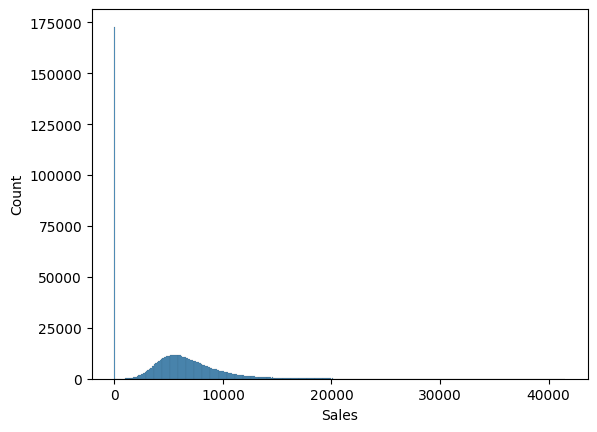

In [11]:
sns.histplot(merged_df,x='Sales')

In [12]:
merged_df=merged_df[merged_df.Open==1].copy()

<Axes: xlabel='Sales', ylabel='Count'>

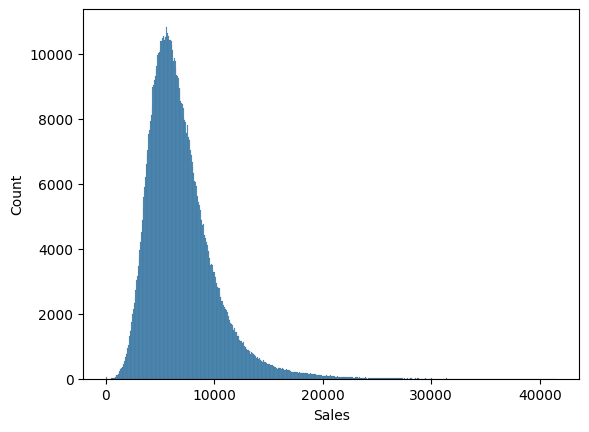

In [13]:
sns.histplot(merged_df,x='Sales')

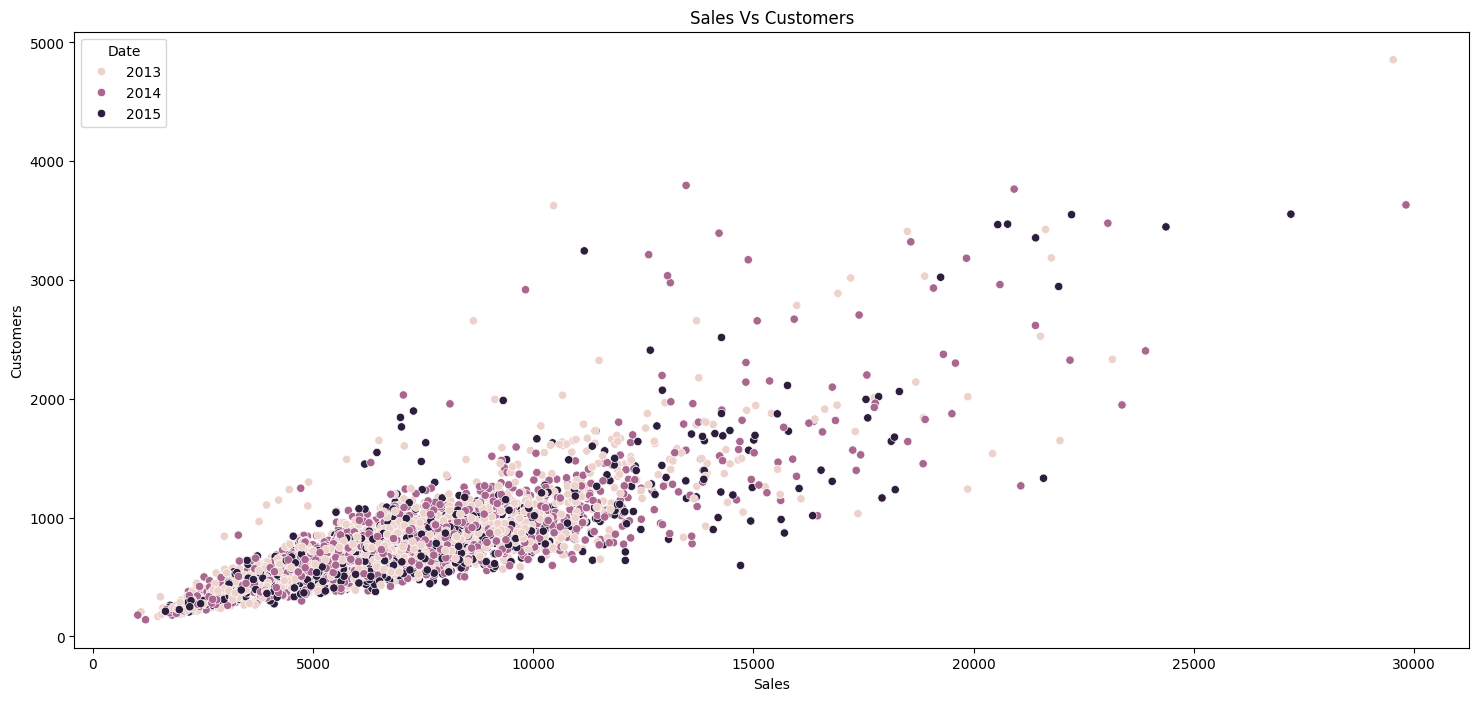

In [14]:
plt.figure(figsize=(18,8))
temp_df=merged_df.sample(4000)
sns.scatterplot(x=temp_df.Sales, y=temp_df.Customers,hue=temp_df.Date.dt.year,)
plt.title('Sales Vs Customers')
plt.show()

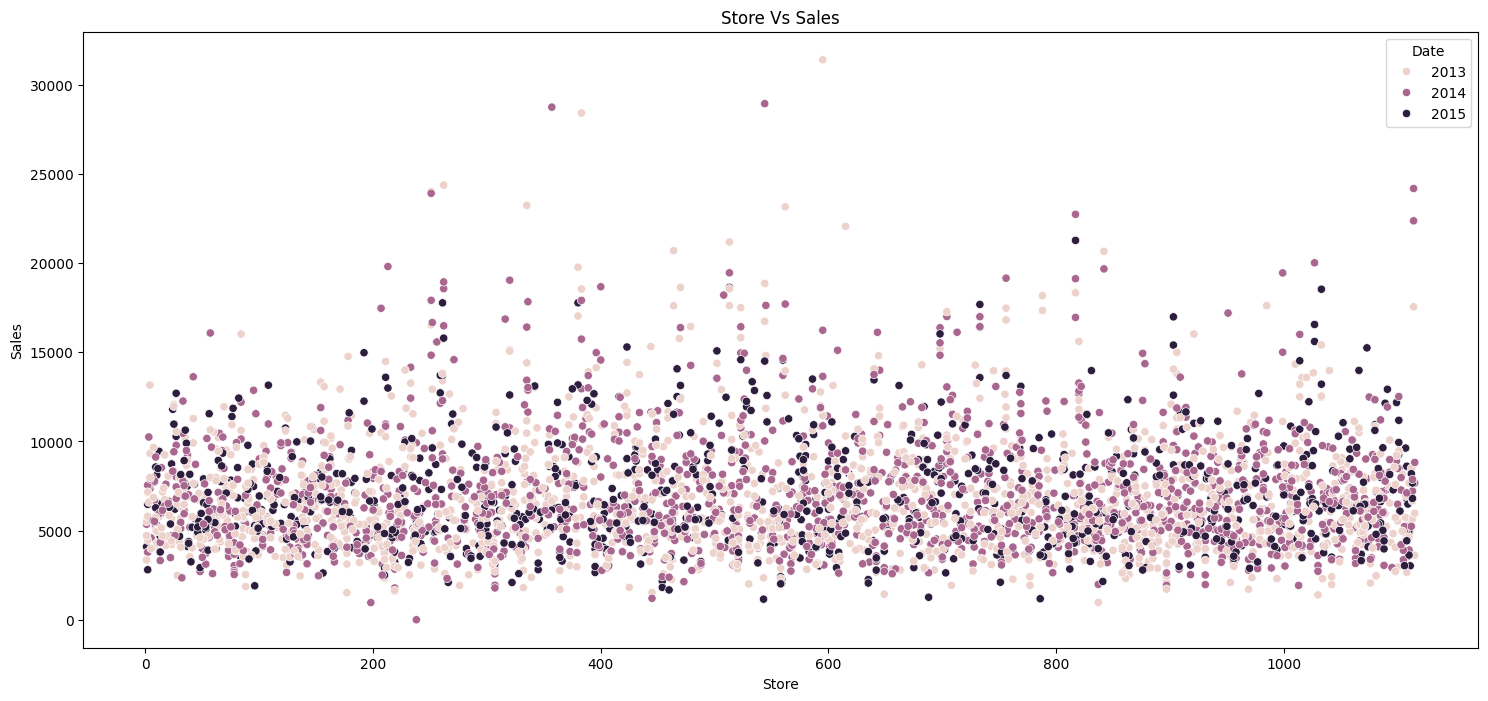

In [15]:
plt.figure(figsize=(18,8))
temp_df=merged_df.sample(4000)
sns.scatterplot(x=temp_df.Store, y=temp_df.Sales,hue=temp_df.Date.dt.year,)
plt.title('Store Vs Sales')
plt.show()

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

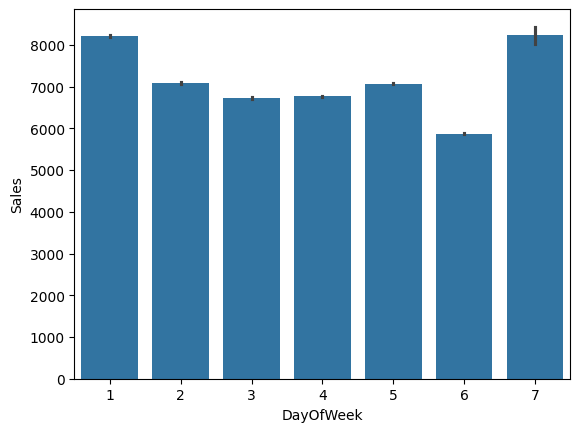

In [16]:
sns.barplot(merged_df,x="DayOfWeek",y='Sales')

<Axes: xlabel='Promo', ylabel='Sales'>

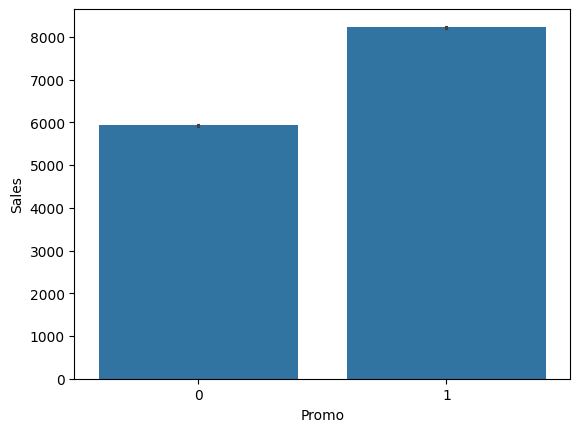

In [17]:
sns.barplot(merged_df,x="Promo",y='Sales')

In [18]:
merged_df.select_dtypes(exclude=['object']).corr()['Sales'].sort_values(ascending=False)

Sales                        1.000000
Customers                    0.823597
Promo                        0.368145
Promo2SinceWeek              0.095311
Date                         0.062757
SchoolHoliday                0.038617
CompetitionOpenSinceYear     0.016101
Store                        0.007710
Promo2SinceYear             -0.034713
CompetitionDistance         -0.036396
CompetitionOpenSinceMonth   -0.043489
Promo2                      -0.127596
DayOfWeek                   -0.178736
Open                              NaN
Name: Sales, dtype: float64

In [19]:
merged_df['Day'] = merged_df.Date.dt.day
merged_df['Month'] = merged_df.Date.dt.month
merged_df['Year'] = merged_df.Date.dt.year

In [20]:
merged_test_df['Day'] = merged_test_df.Date.dt.day
merged_test_df['Month'] = merged_test_df.Date.dt.month
merged_test_df['Year'] = merged_test_df.Date.dt.year

<Axes: xlabel='Year', ylabel='Sales'>

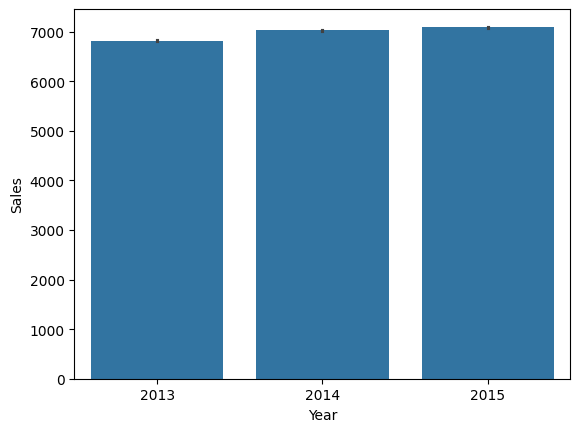

In [21]:
sns.barplot(data=merged_df, x='Year', y='Sales')

<Axes: xlabel='Month', ylabel='Sales'>

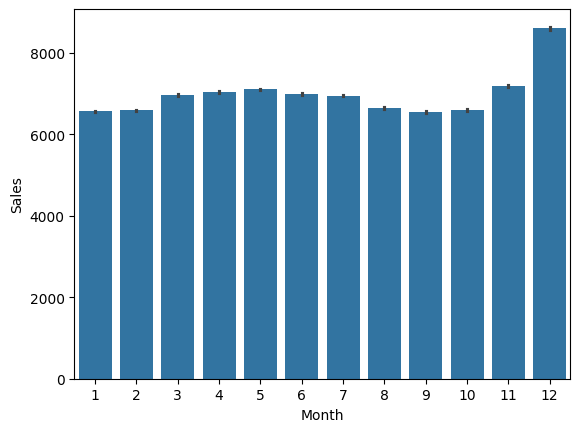

In [22]:
sns.barplot(data=merged_df, x='Month', y='Sales')

In [25]:
len(merged_df)

844392

In [26]:
train_size=int(.75 * len(merged_df))

In [75]:
sorted_df= merged_df.sort_values('Date')
train_df,val_df=sorted_df[:train_size],sorted_df[train_size:]

In [76]:
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment', 'Day', 'Month', 'Year']

In [77]:
target_col = 'Sales'

In [78]:
merged_df[input_cols].nunique()

Store           1115
DayOfWeek          7
Promo              2
StateHoliday       5
StoreType          4
Assortment         3
Day               31
Month             12
Year               3
dtype: int64

In [79]:
train_inputs=train_df[input_cols].copy()
train_targets=train_df[target_col].copy()

In [80]:
val_inputs=val_df[input_cols].copy()
val_targets=val_df[target_col].copy()

In [81]:
test_inputs=merged_test_df[input_cols].copy()

In [82]:
numeric_cols = ['Store', 'Day', 'Month', 'Year']
categorical_cols = ['DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment']

In [83]:
from sklearn.impute import SimpleImputer

In [84]:
imputer=SimpleImputer(strategy="mean").fit(train_inputs[numeric_cols])

In [85]:
train_inputs[numeric_cols] =imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] =imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] =imputer.transform(test_inputs[numeric_cols])

In [86]:
from sklearn.preprocessing import MinMaxScaler

In [87]:
scaler=MinMaxScaler().fit(train_inputs[numeric_cols])

In [88]:
train_inputs[numeric_cols]=scaler.transform(train_inputs[numeric_cols])
test_inputs[numeric_cols]=scaler.transform(test_inputs[numeric_cols])
val_inputs[numeric_cols]=scaler.transform(val_inputs[numeric_cols])

In [89]:
from sklearn.preprocessing import OneHotEncoder

In [90]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore',).fit(train_inputs[categorical_cols].astype(str))
encoded_cols=list(encoder.get_feature_names_out(categorical_cols))

In [91]:
encoded_cols

['DayOfWeek_1',
 'DayOfWeek_2',
 'DayOfWeek_3',
 'DayOfWeek_4',
 'DayOfWeek_5',
 'DayOfWeek_6',
 'DayOfWeek_7',
 'Promo_0',
 'Promo_1',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'StoreType_a',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_a',
 'Assortment_b',
 'Assortment_c']

In [92]:
train_inputs[categorical_cols] = train_inputs[categorical_cols].fillna("Unknown").astype(str)
val_inputs[categorical_cols] = val_inputs[categorical_cols].fillna("Unknown").astype(str)
test_inputs[categorical_cols] = test_inputs[categorical_cols].fillna("Unknown").astype(str)


In [93]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [74]:
print(train_inputs.columns)  # See if the encoded column names exist


Index(['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'StoreType',
       'Assortment', 'Day', 'Month', 'Year', 'DayOfWeek_1', 'DayOfWeek_2',
       'DayOfWeek_3', 'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6',
       'DayOfWeek_7', 'Promo_0', 'Promo_1', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b',
       'Assortment_c'],
      dtype='object')


In [94]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [98]:
def return_mean(inputs):
    return np.full(len(inputs), merged_df.Sales.mean())

In [100]:
train_preds = return_mean(X_train)
train_preds

array([6955.51429076, 6955.51429076, 6955.51429076, ..., 6955.51429076,
       6955.51429076, 6955.51429076])

In [101]:
from sklearn.metrics import mean_squared_error

In [102]:
mean_squared_error(train_preds,train_targets,squared=False)

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


3082.450443277419

In [103]:
mean_squared_error(return_mean(X_val),val_targets,squared=False)

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


3168.6033635047716

In [104]:
def guess_random(inputs):
    lo, hi = merged_df.Sales.min(), merged_df.Sales.max()
    return np.random.random(len(inputs)) * (hi - lo) + lo
train_preds = guess_random(X_train)
train_preds

array([10965.22667053, 32475.35560434, 28956.50791892, ...,
       32571.89472203, 30863.46361728, 37465.86358513])

In [105]:
mean_squared_error(train_preds, train_targets, squared=False)

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


18613.3202927736

In [106]:
mean_squared_error(guess_random(X_val), val_targets, squared=False)

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


18366.564139757647

In [107]:
from sklearn.linear_model import LinearRegression
linreg=LinearRegression()

In [110]:
linreg.fit(X_train,train_targets)

LinearRegression()

In [114]:
train_preds=linreg.predict(X_train)

In [115]:
mean_squared_error(train_preds,train_targets,squared=False)

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


2741.585342064751

In [116]:
def try_model(model):
    # Fit the model
    model.fit(X_train, train_targets)
    
    # Generate predictions
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    
    # Compute RMSE
    train_rmse = mean_squared_error(train_targets, train_preds, squared=False)
    val_rmse = mean_squared_error(val_targets, val_preds, squared=False)
    return train_rmse, val_rmse

In [117]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

In [118]:
try_model(LinearRegression())

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(2741.585342064751, 2817.844267335933)

In [119]:
try_model(Ridge())

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(2741.5871950814444, 2817.7784665409868)

In [120]:
try_model(Lasso())

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(2741.7143904640566, 2817.9472924045217)

In [121]:
try_model(ElasticNet())

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(2879.0432103903954, 2972.6658860503385)

In [122]:
try_model(SGDRegressor())

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(2743.4380292753353, 2832.6152642652237)

In [123]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [124]:
tree = DecisionTreeRegressor(random_state=42)
try_model(tree)

/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/somanathan/Desktop/qgreeks-be-platform-apis/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(0.0, 1559.7378600480247)

In [ ]:
from  sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(n_estimators=100, random_state=42)
try_model(rf)